# 🧹 Customer Churn Dataset — Data Cleaning
**Dataset:** `churnbigml80.csv` &nbsp;|&nbsp; **Rows:** 2,666 &nbsp;|&nbsp; **Columns:** 20

---
### Cleaning Pipeline
1. Load & Inspect
2. Rename Columns
3. Remove Duplicates
4. Fix Data Types
5. Handle Missing Values
6. Detect & Handle Outliers
7. Engineer Derived Features
8. Final Validation & Export

## 1 — Load & Inspect

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)

print('Libraries loaded ✓')

Libraries loaded ✓


In [6]:
df = pd.read_csv('churn-bigml-80.csv')

print(f'Shape : {df.shape}')
print(f'Rows  : {df.shape[0]:,}')
print(f'Cols  : {df.shape[1]}')
df.head()

Shape : (2666, 20)
Rows  : 2,666
Cols  : 20


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.10,110,45.07,197.40,99,16.78,244.70,91,11.01,10.00,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.60,123,27.47,195.50,103,16.62,254.40,103,11.45,13.70,3,3.70,1,False
2,NJ,137,415,No,No,0,243.40,114,41.38,121.20,110,10.30,162.60,104,7.32,12.20,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.40,71,50.90,61.90,88,5.26,196.90,89,8.86,6.60,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.70,113,28.34,148.30,122,12.61,186.90,121,8.41,10.10,3,2.73,3,False


In [7]:
print('=== DATA TYPES ===')
print(df.dtypes)
print()
print('=== BASIC STATISTICS ===')
df.describe(include='all')

=== DATA TYPES ===
State                      object
Account length              int64
Area code                   int64
International plan         object
Voice mail plan            object
Number vmail messages       int64
Total day minutes         float64
Total day calls             int64
Total day charge          float64
Total eve minutes         float64
Total eve calls             int64
Total eve charge          float64
Total night minutes       float64
Total night calls           int64
Total night charge        float64
Total intl minutes        float64
Total intl calls            int64
Total intl charge         float64
Customer service calls      int64
Churn                        bool
dtype: object

=== BASIC STATISTICS ===


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
count,2666,2666.00,2666.00,2666,2666,2666.00,2666.00,2666.00,2666.00,2666.00,2666.00,2666.00,2666.00,2666.00,2666.00,2666.00,2666.00,2666.00,2666.00,2666
unique,51,NaN,NaN,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,WV,NaN,NaN,No,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
freq,88,NaN,NaN,2396,1933,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2278
mean,NaN,100.62,437.44,NaN,NaN,8.02,179.48,100.31,30.51,200.39,100.02,17.03,201.17,100.11,9.05,10.24,4.47,2.76,1.56,NaN
std,NaN,39.56,42.52,NaN,NaN,13.61,54.21,19.99,9.22,50.95,20.16,4.33,50.78,19.42,2.29,2.79,2.46,0.75,1.31,NaN
min,NaN,1.00,408.00,NaN,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.00,43.70,33.00,1.97,0.00,0.00,0.00,0.00,NaN
25%,NaN,73.00,408.00,NaN,NaN,0.00,143.40,87.00,24.38,165.30,87.00,14.05,166.93,87.00,7.51,8.50,3.00,2.30,1.00,NaN
50%,NaN,100.00,415.00,NaN,NaN,0.00,179.95,101.00,30.59,200.90,100.00,17.08,201.15,100.00,9.05,10.20,4.00,2.75,1.00,NaN
75%,NaN,127.00,510.00,NaN,NaN,19.00,215.90,114.00,36.70,235.10,114.00,19.98,236.47,113.00,10.64,12.10,6.00,3.27,2.00,NaN


## 2 — Rename Columns (snake_case)

In [8]:
original_cols = df.columns.tolist()

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_', regex=False)
)

rename_map = dict(zip(original_cols, df.columns.tolist()))
print('Column rename mapping:')
for old, new in rename_map.items():
    marker = '  ✎' if old != new else ''
    print(f'  {old!r:35s} → {new!r}{marker}')

Column rename mapping:
  'State'                             → 'state'  ✎
  'Account length'                    → 'account_length'  ✎
  'Area code'                         → 'area_code'  ✎
  'International plan'                → 'international_plan'  ✎
  'Voice mail plan'                   → 'voice_mail_plan'  ✎
  'Number vmail messages'             → 'number_vmail_messages'  ✎
  'Total day minutes'                 → 'total_day_minutes'  ✎
  'Total day calls'                   → 'total_day_calls'  ✎
  'Total day charge'                  → 'total_day_charge'  ✎
  'Total eve minutes'                 → 'total_eve_minutes'  ✎
  'Total eve calls'                   → 'total_eve_calls'  ✎
  'Total eve charge'                  → 'total_eve_charge'  ✎
  'Total night minutes'               → 'total_night_minutes'  ✎
  'Total night calls'                 → 'total_night_calls'  ✎
  'Total night charge'                → 'total_night_charge'  ✎
  'Total intl minutes'                → 'total_intl_min

## 3 — Remove Duplicates

In [9]:
before = len(df)
df = df.drop_duplicates()
after  = len(df)
removed = before - after

print(f'Rows before : {before:,}')
print(f'Rows after  : {after:,}')
print(f'Duplicates removed: {removed}')

if removed == 0:
    print('✓ No duplicate rows found — dataset is clean on this dimension.')

Rows before : 2,666
Rows after  : 2,666
Duplicates removed: 0
✓ No duplicate rows found — dataset is clean on this dimension.


## 4 — Fix Data Types

In [10]:
print('=== MISSING VALUES ===')
null_summary = pd.DataFrame({
    'missing_count' : df.isnull().sum(),
    'missing_pct'   : (df.isnull().sum() / len(df) * 100).round(2)
})
print(null_summary[null_summary['missing_count'] > 0])
if null_summary['missing_count'].sum() == 0:
    print('✓ No missing values in any column.')

=== MISSING VALUES ===
Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []
✓ No missing values in any column.


In [11]:
# --- 4a. Yes/No strings → binary integer (1 / 0) ---
df['international_plan'] = (df['international_plan'].str.strip() == 'Yes').astype(int)
df['voice_mail_plan']    = (df['voice_mail_plan'].str.strip()    == 'Yes').astype(int)

# --- 4b. Churn bool → int ---
df['churn'] = df['churn'].astype(int)

# --- 4c. area_code is categorical, not numeric ---
df['area_code'] = df['area_code'].astype(str)

print('Updated dtypes:')
print(df[['international_plan', 'voice_mail_plan', 'churn', 'area_code']].dtypes)
print()
print('Value check — international_plan:', df['international_plan'].value_counts().to_dict())
print('Value check — voice_mail_plan   :', df['voice_mail_plan'].value_counts().to_dict())
print('Value check — churn             :', df['churn'].value_counts().to_dict())

Updated dtypes:
international_plan     int64
voice_mail_plan        int64
churn                  int64
area_code             object
dtype: object

Value check — international_plan: {0: 2396, 1: 270}
Value check — voice_mail_plan   : {0: 1933, 1: 733}
Value check — churn             : {0: 2278, 1: 388}


## 5 — Missing Value Visualisation

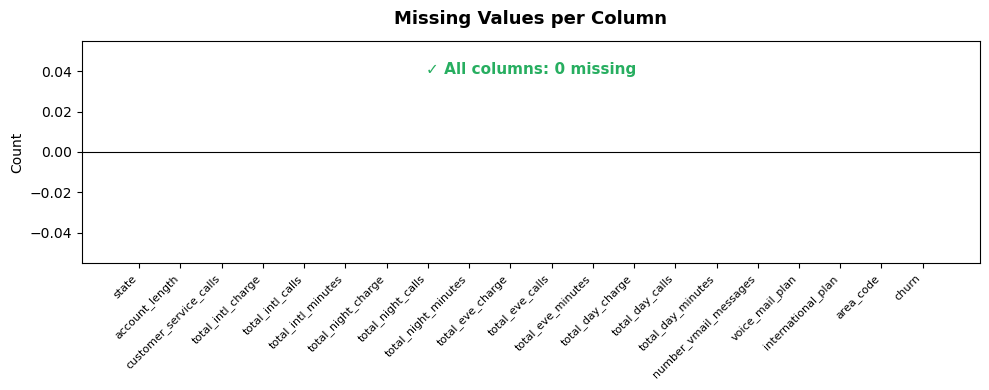

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
missing = df.isnull().sum().sort_values(ascending=False)
bars = ax.bar(missing.index, missing.values,
              color=['#e74c3c' if v > 0 else '#2ecc71' for v in missing.values],
              edgecolor='white', linewidth=0.5)
ax.set_title('Missing Values per Column', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Count')
ax.set_xticklabels(missing.index, rotation=45, ha='right', fontsize=8)
ax.axhline(0, color='black', linewidth=0.8)
ax.annotate('✓ All columns: 0 missing', xy=(0.5, 0.85),
            xycoords='axes fraction', ha='center', fontsize=11,
            color='#27ae60', fontweight='bold')
plt.tight_layout()
plt.show()

## 6 — Outlier Detection & Handling (IQR × 3 Clamp)

In [13]:
usage_cols = [
    'total_day_minutes',   'total_eve_minutes',
    'total_night_minutes', 'total_intl_minutes',
    'total_day_charge',    'total_eve_charge',
    'total_night_charge',  'total_intl_charge',
    'customer_service_calls',
]

# ── Before / after snapshot ──
summary_before = df[usage_cols].describe().T[['min','25%','50%','75%','max']]

outlier_report = []
for col in usage_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR    = Q3 - Q1
    lo     = Q1 - 3 * IQR
    hi     = Q3 + 3 * IQR
    n_out  = ((df[col] < lo) | (df[col] > hi)).sum()
    df[col] = df[col].clip(lower=lo, upper=hi)
    outlier_report.append({'column': col, 'lower_fence': round(lo,2),
                           'upper_fence': round(hi,2), 'values_clamped': n_out})

report_df = pd.DataFrame(outlier_report)
print('=== OUTLIER CLAMP REPORT (IQR × 3) ===')
print(report_df.to_string(index=False))

=== OUTLIER CLAMP REPORT (IQR × 3) ===
                column  lower_fence  upper_fence  values_clamped
     total_day_minutes       -74.10       433.40               0
     total_eve_minutes       -44.10       444.50               0
   total_night_minutes       -41.72       445.12               0
    total_intl_minutes        -2.30        22.90               0
      total_day_charge       -12.58        73.66               0
      total_eve_charge        -3.74        37.77               0
    total_night_charge        -1.87        20.02               0
     total_intl_charge        -0.61         6.18               0
customer_service_calls        -2.00         5.00              28


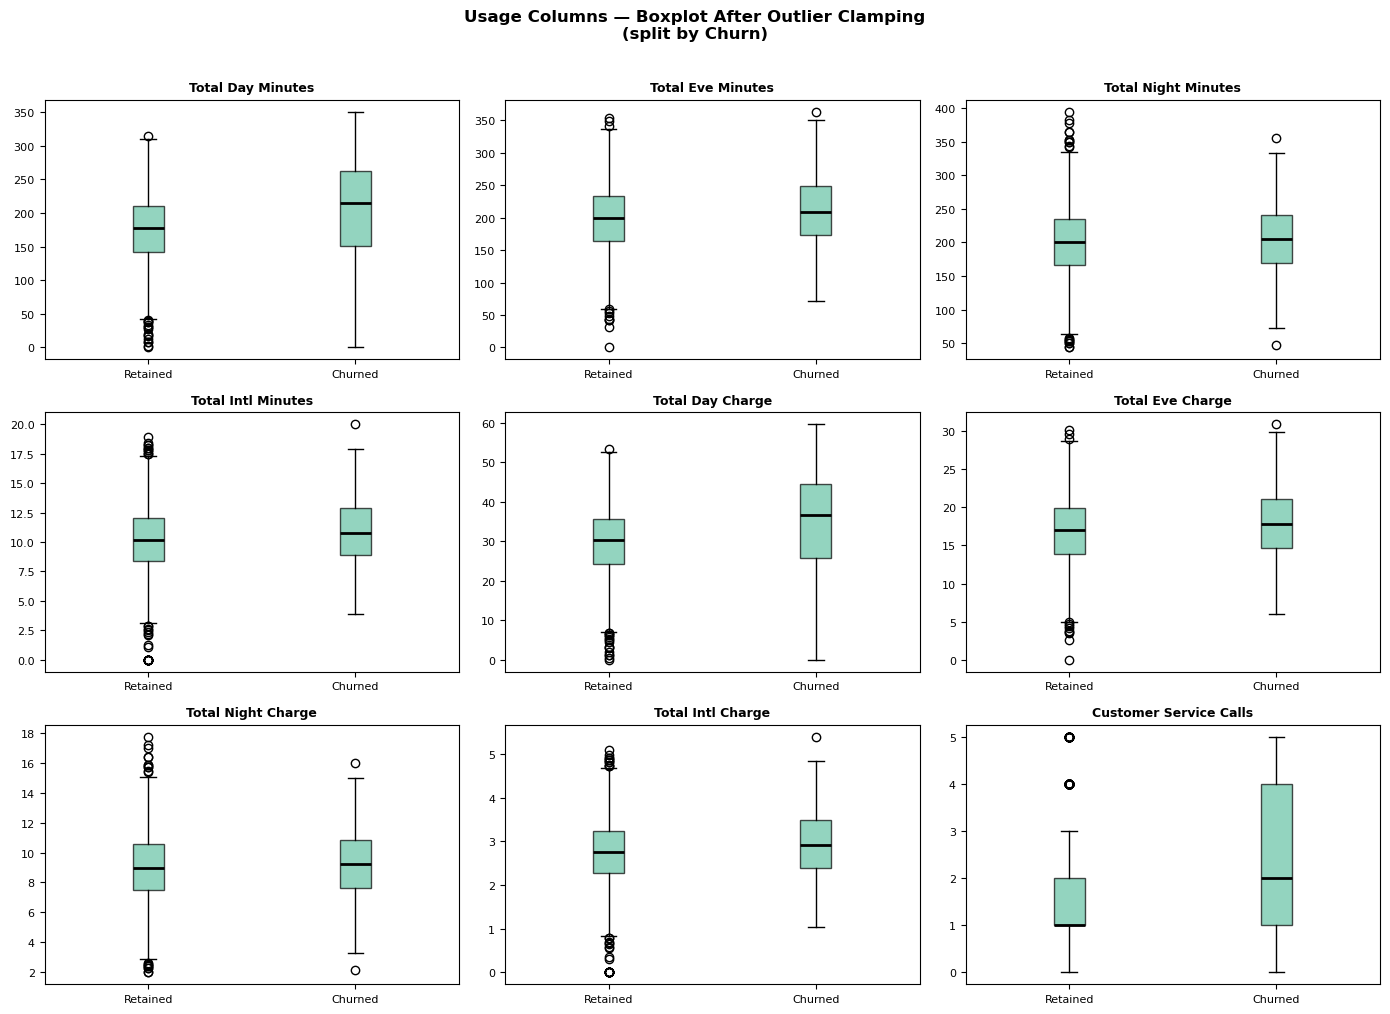

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

palette = sns.color_palette('Set2', 2)

for i, col in enumerate(usage_cols):
    ax = axes[i]
    churned  = df[df['churn'] == 1][col]
    retained = df[df['churn'] == 0][col]
    ax.boxplot([retained, churned],
               labels=['Retained', 'Churned'],
               patch_artist=True,
               boxprops=dict(facecolor=palette[0], alpha=0.7),
               medianprops=dict(color='black', linewidth=2))
    ax.set_title(col.replace('_', ' ').title(), fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=8)

plt.suptitle('Usage Columns — Boxplot After Outlier Clamping\n(split by Churn)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7 — Feature Engineering (Derived Columns)

In [15]:
# ── Total charge & minutes ──────────────────────────────────────────────────
df['total_charge'] = (
    df['total_day_charge']
    + df['total_eve_charge']
    + df['total_night_charge']
    + df['total_intl_charge']
)

df['total_minutes'] = (
    df['total_day_minutes']
    + df['total_eve_minutes']
    + df['total_night_minutes']
    + df['total_intl_minutes']
)

# ── Spend tier (quartile-based) ─────────────────────────────────────────────
df['spend_tier'] = pd.qcut(
    df['total_charge'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Premium']
)

# ── High CS-calls flag (≥4 calls → known churn cliff) ───────────────────────
df['high_cs_calls'] = (df['customer_service_calls'] >= 4).astype(int)

# ── Composite risk score (0-4) ───────────────────────────────────────────────
df['risk_score'] = (
    df['international_plan']
    + df['high_cs_calls']
    + (1 - df['voice_mail_plan'])
    + (df['spend_tier'] == 'Premium').astype(int)
)

print('New columns added:')
new_cols = ['total_charge', 'total_minutes', 'spend_tier', 'high_cs_calls', 'risk_score']
print(df[new_cols].head(8))
print()
print('Spend tier distribution:')
print(df['spend_tier'].value_counts().sort_index())
print()
print('Risk score distribution:')
print(df['risk_score'].value_counts().sort_index())

New columns added:
   total_charge  total_minutes spend_tier  high_cs_calls  risk_score
0         75.56         717.20    Premium              0           1
1         59.24         625.20     Medium              0           0
2         62.29         539.40       High              0           1
3         66.80         564.80    Premium              0           3
4         52.09         512.00        Low              0           2
5         67.61         654.20    Premium              0           3
6         78.31         786.80    Premium              0           1
7         46.90         479.00        Low              0           2

Spend tier distribution:
spend_tier
Low        667
Medium     666
High       667
Premium    666
Name: count, dtype: int64

Risk score distribution:
risk_score
0     449
1    1467
2     643
3     102
4       5
Name: count, dtype: int64


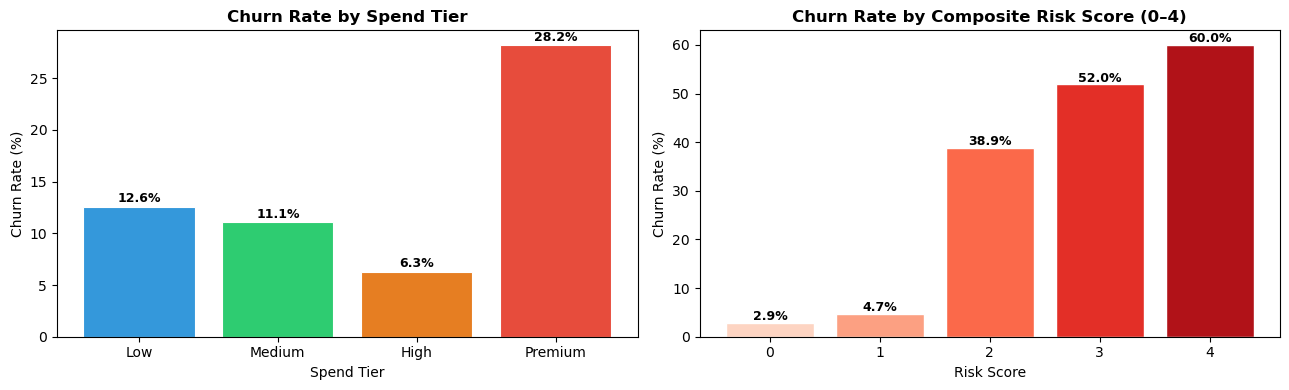

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Plot 1: Churn rate by spend tier ─────────────────────────────────────────
tier_order = ['Low', 'Medium', 'High', 'Premium']
tier_stats = (
    df.groupby('spend_tier', observed=True)['churn']
    .mean()
    .reindex(tier_order) * 100
)
colors = ['#3498db', '#2ecc71', '#e67e22', '#e74c3c']
axes[0].bar(tier_stats.index, tier_stats.values, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Churn Rate by Spend Tier', fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_xlabel('Spend Tier')
for i, v in enumerate(tier_stats.values):
    axes[0].text(i, v + 0.4, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

# ── Plot 2: Churn rate by composite risk score ────────────────────────────────
risk_stats = df.groupby('risk_score')['churn'].mean() * 100
axes[1].bar(risk_stats.index.astype(str), risk_stats.values,
            color=sns.color_palette('Reds', len(risk_stats)), edgecolor='white')
axes[1].set_title('Churn Rate by Composite Risk Score (0–4)', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xlabel('Risk Score')
for i, (score, v) in enumerate(risk_stats.items()):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 8 — Final Validation & Export

In [17]:
print('=' * 55)
print('  FINAL VALIDATION REPORT')
print('=' * 55)
print(f'  Shape             : {df.shape}')
print(f'  Null values       : {df.isnull().sum().sum()}')
print(f'  Duplicate rows    : {df.duplicated().sum()}')
print(f'  Total customers   : {len(df):,}')
print(f'  Churned           : {df["churn"].sum():,}  ({df["churn"].mean()*100:.2f}%)')
print(f'  Retained          : {(df["churn"]==0).sum():,}  ({(df["churn"]==0).mean()*100:.2f}%)')
print()
print('  Columns in clean dataset:')
for col in df.columns:
    tag = ' ← NEW' if col in ['total_charge','total_minutes','spend_tier','high_cs_calls','risk_score'] else ''
    print(f'    {col}{tag}')
print('=' * 55)

# Assertions
assert df.isnull().sum().sum() == 0,  'FAIL: nulls remain'
assert df.duplicated().sum()   == 0,  'FAIL: duplicates remain'
assert df['churn'].isin([0,1]).all(), 'FAIL: churn not binary'
print('  All assertions passed ✓')

  FINAL VALIDATION REPORT
  Shape             : (2666, 25)
  Null values       : 0
  Duplicate rows    : 0
  Total customers   : 2,666
  Churned           : 388  (14.55%)
  Retained          : 2,278  (85.45%)

  Columns in clean dataset:
    state
    account_length
    area_code
    international_plan
    voice_mail_plan
    number_vmail_messages
    total_day_minutes
    total_day_calls
    total_day_charge
    total_eve_minutes
    total_eve_calls
    total_eve_charge
    total_night_minutes
    total_night_calls
    total_night_charge
    total_intl_minutes
    total_intl_calls
    total_intl_charge
    customer_service_calls
    churn
    total_charge ← NEW
    total_minutes ← NEW
    spend_tier ← NEW
    high_cs_calls ← NEW
    risk_score ← NEW
  All assertions passed ✓


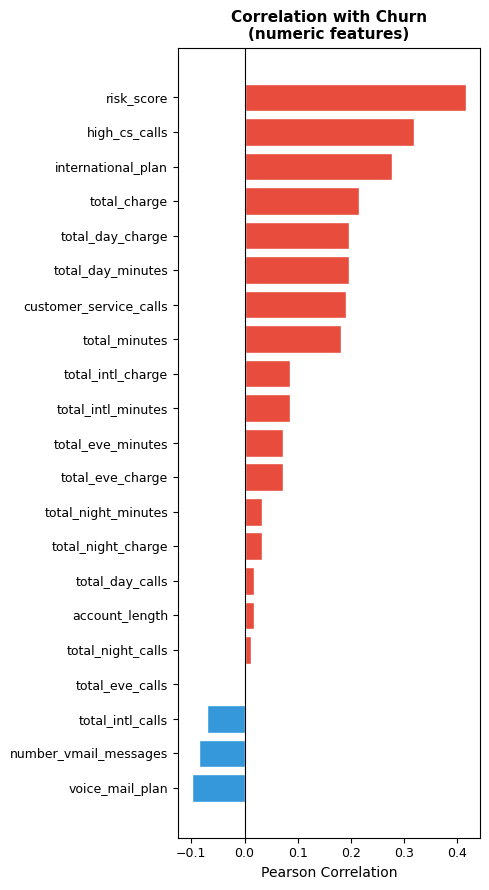

In [18]:
# Correlation heatmap of numeric columns vs Churn
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()[['churn']].drop('churn').sort_values('churn')

fig, ax = plt.subplots(figsize=(5, 9))
colors_bar = ['#e74c3c' if v > 0 else '#3498db' for v in corr['churn']]
ax.barh(corr.index, corr['churn'], color=colors_bar, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlation with Churn\n(numeric features)', fontweight='bold', fontsize=11)
ax.set_xlabel('Pearson Correlation')
ax.tick_params(labelsize=9)
plt.tight_layout()
plt.show()

In [21]:
from sqlalchemy import create_engine

username='root'
password='5656'
host='localhost'
port='3306'
database='churn'
engine=create_engine(f'mysql+pymysql://{username}:{password}@{host}:{port}/{database}')

table_name="customers"
df.to_sql(table_name, con=engine, if_exists='replace', index=False)
pd.read_sql("Select * from customers LIMIT 5;", con=engine )

,state,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,customer_service_calls,churn,total_charge,total_minutes,spend_tier,high_cs_calls,risk_score
0,KS,128,415,0,1,25,265.10,110,45.07,197.40,99,16.78,244.70,91,11.01,10.00,3,2.70,1,0,75.56,717.20,Premium,0,1
1,OH,107,415,0,1,26,161.60,123,27.47,195.50,103,16.62,254.40,103,11.45,13.70,3,3.70,1,0,59.24,625.20,Medium,0,0
2,NJ,137,415,0,0,0,243.40,114,41.38,121.20,110,10.30,162.60,104,7.32,12.20,5,3.29,0,0,62.29,539.40,High,0,1
3,OH,84,408,1,0,0,299.40,71,50.90,61.90,88,5.26,196.90,89,8.86,6.60,7,1.78,2,0,66.80,564.80,Premium,0,3
4,OK,75,415,1,0,0,166.70,113,28.34,148.30,122,12.61,186.90,121,8.41,10.10,3,2.73,3,0,52.09,512.00,Low,0,2
